In [6]:
%%capture
!pip install scikit-optimize scipy

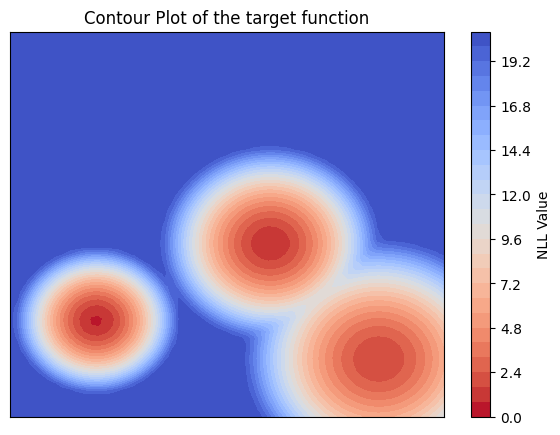

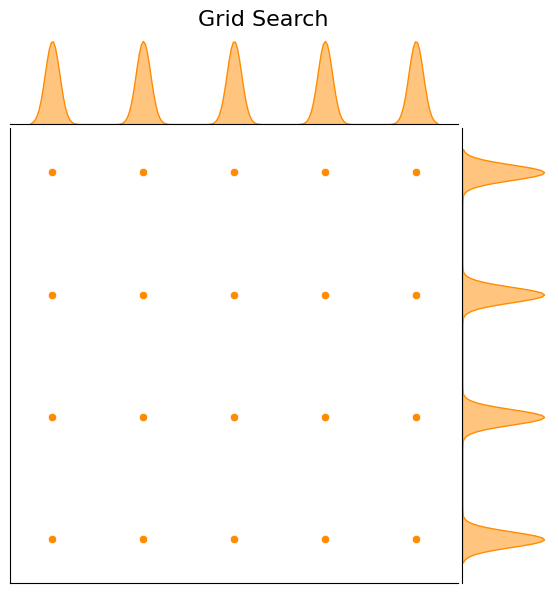

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


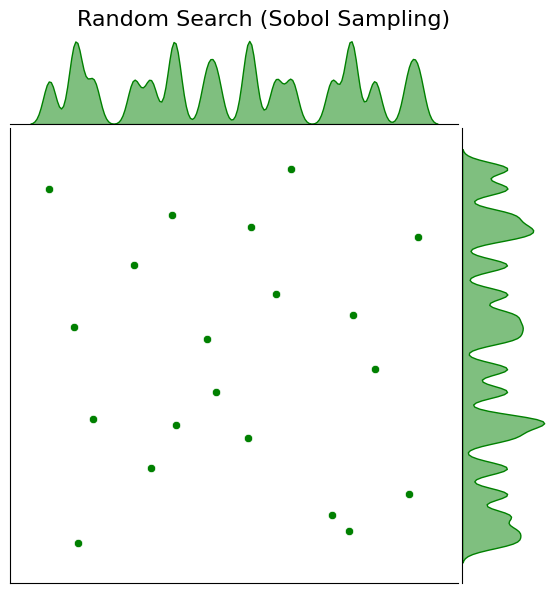

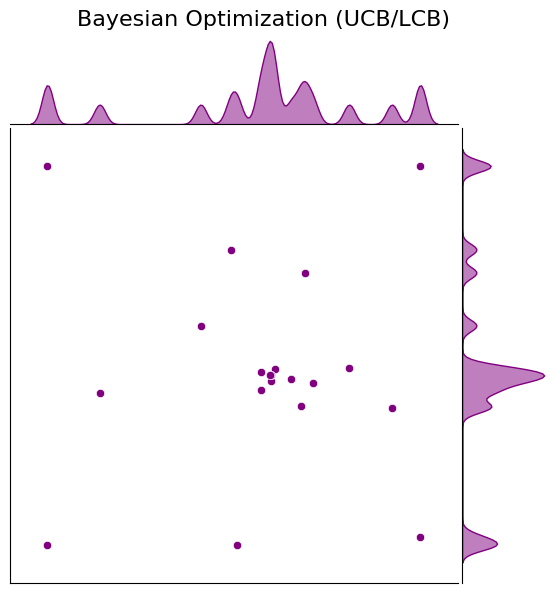

Best results:
  - Grid Search:    NLL=5.9848 at (lambda1, lambda2)=[25.075  0.334]
  - Random Search:  NLL=2.9773 at (lambda1, lambda2)=[92.90378869  0.13098381]
  - Bayesian Opt.:  NLL=0.9219 at (lambda1, lambda2)=[60.09362907  0.45047802]


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
# Import gp_minimize from scikit-optimize for Bayesian Optimization with UCB (LCB)
from skopt import gp_minimize

# -------------------------------
# 1) Setup
# -------------------------------
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080"
}

# -------------------------------
# 2) Define a three-Gaussian mixture negative log-likelihood (sharp minima)
# -------------------------------
def three_gaussian_neg_log_likelihood_sharp(x):
    x = np.atleast_2d(x)
    lam1, lam2 = x[:, 0], x[:, 1]

    # Means
    mu1 = np.array([20, 0.25])
    mu2 = np.array([60, 0.45])
    mu3 = np.array([85, 0.15])

    # Smaller standard deviations => sharper peaks
    sigma1 = np.array([3, 0.03])
    sigma2 = np.array([4, 0.04])
    sigma3 = np.array([5, 0.05])

    # Weights
    w1, w2, w3 = 0.3, 0.4, 0.3

    def diag_gauss_pdf(xx, mu, sigma):
        diff = (xx - mu) / sigma
        exponent = -0.5 * np.sum(diff**2, axis=1)
        norm_const = 2.0 * np.pi * sigma[0] * sigma[1]
        return np.exp(exponent) / norm_const

    g1 = diag_gauss_pdf(x, mu1, sigma1)
    g2 = diag_gauss_pdf(x, mu2, sigma2)
    g3 = diag_gauss_pdf(x, mu3, sigma3)

    likelihood = w1*g1 + w2*g2 + w3*g3
    return -np.log(likelihood + 1e-9)

# Parameter ranges
lambda1_range = (0.1, 100)
lambda2_range = (0.001, 1)

# -------------------------------
# 3) Contour plot of the NLL (Warm -> Low, Cool -> High)
# -------------------------------
def plot_target_contour(f, lam1_range, lam2_range, n=60):
    lam1_vals = np.linspace(*lam1_range, n)
    lam2_vals = np.linspace(*lam2_range, n)
    L1, L2 = np.meshgrid(lam1_vals, lam2_vals)
    
    # Evaluate NLL
    Z = f(np.column_stack([L1.ravel(), L2.ravel()])).reshape(L1.shape)
    
    cmap_reversed = plt.cm.coolwarm_r
    plt.figure(figsize=(7, 5))
    contour = plt.contourf(L1, L2, Z, levels=30, cmap=cmap_reversed)
    plt.colorbar(contour, label='NLL Value')
    plt.xticks([])
    plt.yticks([])
    plt.title('Contour Plot of the target function')
    plt.show()

plot_target_contour(three_gaussian_neg_log_likelihood_sharp, lambda1_range, lambda2_range, n=60)

# -------------------------------
# 4) Utility for scatter + marginals
# -------------------------------
def plot_with_marginals(lambda1, lambda2, color, title):
    g = sns.jointplot(
        x=lambda1,
        y=lambda2,
        kind="scatter",
        marginal_ticks=False,
        color=color_palette[color],
        height=6,
        ratio=5,
        space=0.05
    )

    g.ax_marg_x.clear()
    g.ax_marg_y.clear()

    sns.kdeplot(
        x=lambda1, ax=g.ax_marg_x, fill=True,
        color=color_palette[color], alpha=0.5, bw_adjust=0.1
    )
    sns.kdeplot(
        y=lambda2, ax=g.ax_marg_y, fill=True,
        color=color_palette[color], alpha=0.5, bw_adjust=0.1
    )

    for ax in [g.ax_marg_x, g.ax_marg_y]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(left=False, right=False, labelleft=False,
                       labelbottom=False, bottom=False, top=False)

    g.set_axis_labels()
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

# -------------------------------
# 5) Grid Search
# -------------------------------
lambda1_grid, lambda2_grid = np.meshgrid(
    np.linspace(*lambda1_range, 5),
    np.linspace(*lambda2_range, 4)
)
grid_points = np.column_stack([lambda1_grid.ravel(), lambda2_grid.ravel()])
grid_vals = three_gaussian_neg_log_likelihood_sharp(grid_points)

best_grid_idx = np.argmin(grid_vals)
best_grid_val = grid_vals[best_grid_idx]
best_grid_params = grid_points[best_grid_idx]

plot_with_marginals(
    grid_points[:, 0],
    grid_points[:, 1],
    "dark_orange",
    "Grid Search"
)

n_grid_points = grid_points.shape[0]

# -------------------------------
# 6) Random Search (Sobol)
# -------------------------------
n_search = n_grid_points  # Total number of search points

sobol_seq = Sobol(d=2, scramble=True, seed=123).random(n_search)
lam1_rand = lambda1_range[0] + sobol_seq[:, 0] * (lambda1_range[1] - lambda1_range[0])
lam2_rand = lambda2_range[0] + sobol_seq[:, 1] * (lambda2_range[1] - lambda2_range[0])
rand_points = np.column_stack([lam1_rand, lam2_rand])
rand_vals = three_gaussian_neg_log_likelihood_sharp(rand_points)

best_rand_idx = np.argmin(rand_vals)
best_rand_val = rand_vals[best_rand_idx]
best_rand_params = rand_points[best_rand_idx]

plot_with_marginals(
    rand_points[:, 0],
    rand_points[:, 1],
    "green",
    "Random Search (Sobol Sampling)"
)

# -------------------------------
# 7) Bayesian Optimization with UCB (Fixed Total Points) using scikit-optimize
# -------------------------------
# Define an objective that accepts a list and returns a scalar.
def objective(x):
    # np.atleast_2d ensures compatibility with our function
    return three_gaussian_neg_log_likelihood_sharp(x)[0]

# Define the bounds in the format expected by skopt (list of (min, max) tuples).
bounds = [lambda1_range, lambda2_range]

# Use UCB acquisition via the "LCB" option.
# Here, n_calls is set to n_search (the same as grid points), with a few initial random points.
res = gp_minimize(
    func=objective,
    dimensions=bounds,
    n_calls=n_search,
    n_initial_points=min(5, n_search),
    acq_func="LCB",  # Using the default settings for LCB
    kappa=1.64, # More exploitation than 1.96
    random_state=123
)

# Extract evaluated points and corresponding values.
X_train = np.array(res.x_iters)
bayes_vals = three_gaussian_neg_log_likelihood_sharp(X_train)
best_bayes_idx = np.argmin(bayes_vals)
best_bayes_val = bayes_vals[best_bayes_idx]
best_bayes_params = X_train[best_bayes_idx]

plot_with_marginals(
    X_train[:, 0],
    X_train[:, 1],
    "purple",
    "Bayesian Optimization (UCB/LCB)"
)

# -------------------------------
# 8) Print final best results
# -------------------------------
print("Best results:")
print(f"  - Grid Search:    NLL={best_grid_val:.4f} at (lambda1, lambda2)={best_grid_params}")
print(f"  - Random Search:  NLL={best_rand_val:.4f} at (lambda1, lambda2)={best_rand_params}")
print(f"  - Bayesian Opt.:  NLL={best_bayes_val:.4f} at (lambda1, lambda2)={best_bayes_params}")